In [1]:
import os
import logging, timeit
#from btEngine2.DataLoader import DataLoader
from btEngine2.MarketData import MarketData
from btEngine2.TradingRule import TradingRule

import platform
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.0f}' if abs(x) >= 1000 else (f'{x:.2f}' if abs(x) < 10 else f'{x:.1f}')
# Detect operating system
if platform.system() == "Windows":
    ticker_csv_path = r'G:\Projects\BackTesting1.0\Data\Inputs\TickerList-Futs.csv'
    save_directory = r"G:\Projects\BackTesting1.0\Data\Bloomberg\Futures"
    helper_directory = r'G:\Projects\BackTesting1.0\Data\Bloomberg\HelperFiles'
    bt_folder = r'BackTests\seasn_resrch'
else:  # Assume macOS for other cases
    ticker_csv_path = r'Data/Inputs/TickerList-Futs.csv'
    save_directory = r"Data/Bloomberg/Futures"
    helper_directory = r'Data/Bloomberg/HelperFiles'
    bt_folder = r'BackTests/seasn_resrch'

# Define paths to auxiliary data for MarketData
tick_values_path = os.path.join(helper_directory, 'fut_val_pt.parquet')
fx_rates_path = os.path.join(helper_directory, 'fxHist.parquet')

# Initialize the MarketData
market_data = MarketData(
    base_directory=save_directory,
    tick_values_path=tick_values_path,
    fx_rates_path=fx_rates_path,
    instrument_type="Futures",
    n_threads=8,  # Number of threads for parallel data loading
    log_level=logging.ERROR  # Set to DEBUG for more detailed logs
)


In [2]:
tick = 'SM1 Index'
# Access data for a specific ticker
try:
    test_df = market_data.get_ticker_data(tick)
    print(test_df)
except ValueError as e:
    print(e)

# Access all preprocessed data
all_data = market_data.get_data()
print(f"Total tickers loaded: {len(all_data)}")

# Access FX rates
fx_rates = market_data.get_fx_rates()
# Access tick values
tick_values = market_data.get_tick_values()
# Access asset classes
asset_classes = market_data.get_asset_classes()

#market_data = market_data.date_filter(start_date='01012010')

shape: (6_735, 13)
┌────────────┬─────────┬─────────┬─────────┬───┬───────────┬─────────┬──────────────┬──────────────┐
│ Date       ┆ Open    ┆ High    ┆ Low     ┆ … ┆ Carry     ┆ FX_Rate ┆ Tick_Value_B ┆ Tick_Value_U │
│ ---        ┆ ---     ┆ ---     ┆ ---     ┆   ┆ ---       ┆ ---     ┆ ase          ┆ SD           │
│ date       ┆ f64     ┆ f64     ┆ f64     ┆   ┆ f64       ┆ f64     ┆ ---          ┆ ---          │
│            ┆         ┆         ┆         ┆   ┆           ┆         ┆ f64          ┆ f64          │
╞════════════╪═════════╪═════════╪═════════╪═══╪═══════════╪═════════╪══════════════╪══════════════╡
│ 1998-01-05 ┆ 2533.0  ┆ 2751.0  ┆ 2751.0  ┆ … ┆ null      ┆ 0.6754  ┆ 10.0         ┆ 6.754        │
│ 1998-01-06 ┆ 2533.0  ┆ 2751.0  ┆ 2751.0  ┆ … ┆ null      ┆ 0.6738  ┆ 10.0         ┆ 6.738        │
│ 1998-01-07 ┆ 2533.0  ┆ 2751.0  ┆ 2751.0  ┆ … ┆ null      ┆ 0.6765  ┆ 10.0         ┆ 6.765        │
│ 1998-01-08 ┆ 2970.2  ┆ 2970.2  ┆ 2970.2  ┆ … ┆ null      ┆ 0.6772  ┆ 1

In [3]:

pSizeParams = {
    'AssetVol': 5_000_000,  # Target asset volatility in USD
    'VolLookBack': 30,
    'VolMethod': 'ewm'  # Lookback period for volatility calculation
}


In [4]:
from btEngine2.Rules.Seasonality.ultimo import *

In [5]:
test_sig = ultimo_long(test_df, 5, 5).to_pandas()

test_sig.to_clipboard()

In [6]:
test_sig = ultimo_long(test_df, 5, 5, (2,180,3,0.6)).to_pandas()

test_sig.to_clipboard()

/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [10:21:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [10:21:36] WARNING: /Users/runner/work/xgboost/xgboost/src/common/error_msg.cc:52: Empty dataset at worker: 0
  warnings.warn(smsg, UserWarning)


In [7]:
ultimo_params = dict(days_before_end=5, days_after_start=5)
skew_sizing = dict(AssetVol=r'Data/Inputs/AssetSizing-Futs.csv', VolLookBack=30, VolMethod='ewm')

exclude = ['eq-divf', 'eq-vol'] + [x for x in asset_classes if 'comm-' in x] + [x for x in asset_classes if 'fx-' in x] + ['stir']


In [8]:
ultimo_eff = TradingRule(
    market_data=market_data,
    trading_rule_function=ultimo_long,
    trading_params=ultimo_params,
    position_sizing_params=skew_sizing,  # Define as needed
    excl_ac=exclude,
    sizing_rf=0.2,
    log_level=logging.ERROR,
    bt_folder = bt_folder
)

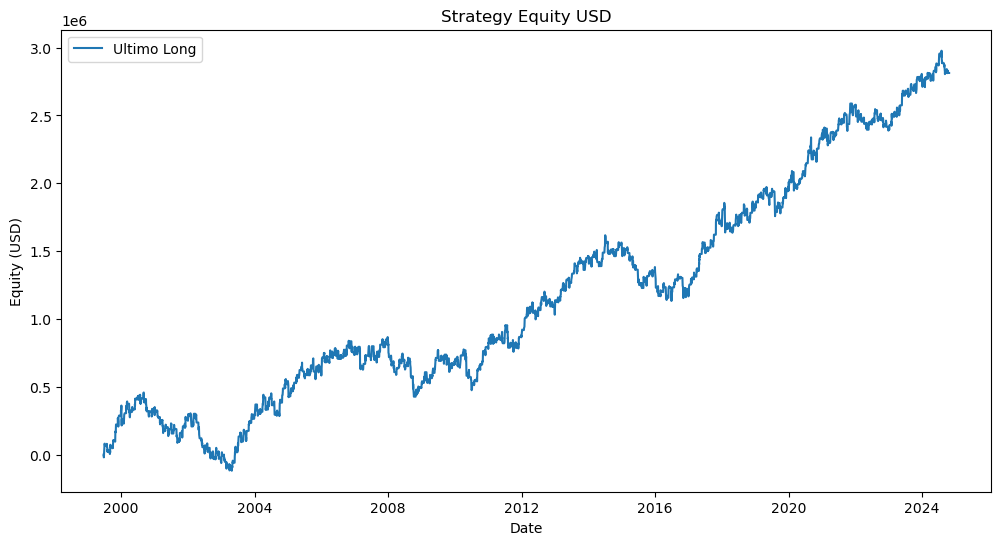

In [9]:
ticker = 'NQ1 Index'

estest_long = ultimo_eff.backtest_asset(ticker)

# Plot the Strategy_Equity_USD for each and total on the same plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(estest_long['Date'], estest_long['Strategy_Equity_USD'], label='Ultimo Long')
plt.legend()
plt.title('Strategy Equity USD')
plt.xlabel('Date')
plt.ylabel('Equity (USD)')
plt.show()


In [10]:
ultimo_eff.plot_equity(byac=True)

,eq-us,eq-eu,fi-us,fi-eu,eq-em,eq-as,fi-as,crypto,Total
Date,,,,,,,,,
1980-01-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...
2024-10-16,"8,560,877","16,905,126","33,660,118","24,485,836","6,825,573","2,384,033","3,928,908","1,301,725","98,052,196"
2024-10-17,"8,560,877","16,905,126","33,660,118","24,485,836","6,825,573","2,384,033","3,928,908","1,301,725","98,052,196"
2024-10-18,"8,560,877","16,905,126","33,660,118","24,485,836","6,825,573","2,384,033","3,928,908","1,301,725","98,052,196"


In [11]:
startat = '01012000'
slong_stats = ultimo_eff.calculate_statistics(byac=True, start_date=startat) 

In [12]:

slong_stats.iloc[:, :20]


,Total PnL,Average Ann. PnL,Average Ann. Vol,Sharpe Ratio (ann.),Sortino Ratio (ann.),Max drawdown,Average drawdown,Max drawdown Duration,Avg Drawdown Duration,Total Number of Drawdowns,Drawdowns per year,HWM PnL,Exposure Time,Daily PnL Skew,Weekly PnL Skew,Monthly PnL Skew,Quarterly PnL Skew,Yearly PnL Skew,Daily Left Tail,Daily Right Tail
Column,,,,,,,,,,,,,,,,,,,,
eq-us,"7,914,422","308,450","666,181",0.46,0.39,"1,718,935","491,804",1435,59.2,101,3.94,"8,653,455",6466,-1.11,-0.98,-0.71,-0.16,0.02,25.6,-22.5
eq-eu,"10,888,081","424,342","1,086,280",0.39,0.35,"3,054,923","866,003",1736,66.3,91,3.55,"11,770,094",6466,-0.72,-0.72,-0.69,-0.18,0.47,30.2,-26.6
fi-us,"17,795,456","693,544","1,548,380",0.45,0.45,"5,905,056","1,517,139",1430,67.5,90,3.51,"21,639,921",6466,0.07,0.31,0.34,0.01,-0.21,25.4,-24.1
fi-eu,"19,608,761","764,214","1,241,300",0.62,0.55,"5,266,022","1,187,411",977,49.1,118,4.60,"22,909,360",6466,-0.45,-0.24,-0.40,-0.19,-0.25,19.2,-17.7
eq-em,"6,509,576","253,698","374,795",0.68,0.69,"1,017,687","248,188",722,44.3,134,5.22,"6,578,841",6466,3.65,1.11,0.36,0.20,0.10,15.7,-16.5
eq-as,"2,729,340","106,371","273,905",0.39,0.35,"660,911","233,540",1563,75.8,81,3.16,"2,971,357",6466,-0.74,-0.69,-0.58,-0.12,0.33,31.4,-26.3
fi-as,"1,501,405","58,514","293,633",0.20,0.19,"1,575,079","626,347",3301,117.6,53,2.07,"2,110,847",6466,0.17,0.12,0.26,0.33,0.11,57.6,-53.8
crypto,"1,301,725","50,732","111,010",0.46,0.23,"469,550","83,033",361,28.8,53,2.07,"1,744,175",6466,1.13,2.24,2.19,1.41,2.30,23.6,-29.3
Total,"68,248,767","2,659,865","2,787,035",0.95,0.88,"8,064,417","1,589,916",778,32.8,175,6.82,"70,612,362",6466,-0.48,-0.25,-0.60,-0.52,-0.72,12.4,-11.4


In [13]:
metric = 'PnL'

tr = ultimo_eff

t = tr.perf_table(metric=metric)
t = t.iloc[:, :]
t = t.fillna('')
if metric == 'pnl' or metric == 'vol' or metric=='maxdd':
    t = t.replace(0, '')
    t = t.map(lambda x: x / 1_000_000 if isinstance(x, (int, float)) else x)
t

Period                      2024      2023       2022      2021      2020  \
AssetClass Asset                                                            
Unknown    Total       1,320,145 3,452,750 -6,121,659 2,868,986 6,719,534   
crypto     BTC1 Curncy   111,325    91,375     50,475   171,950   320,775   
           DCR1 Curncy  -115,350   183,450     64,100   336,850      0.00   
eq-as      NK1 Index      27,495   134,454    -99,832    17,377   106,948   
           TP1 Index      38,857   152,554    -96,720    59,581    11,058   
           XP1 Index      49,281    50,307     -5,364   156,236   -30,257   
eq-em      HC1 Index     121,789    45,406      6,618  -174,933    50,733   
           KM1 Index        0.00      0.00       0.00      0.00      0.00   
           MES1 Index     33,790    55,840    -28,665    17,195   167,000   
           QZ1 Index     -77,233    83,310    -21,680   124,089    38,637   
           XB1 Index     -23,078   -14,371     14,537    60,221     9,755   
           XU1 Index     103,393   -17,641    -40,843   -27,664   262,879   
           ZVL1 Index     26,520   263,900     48,890   234,020   160,560   
eq-eu      CA1 Index     127,435   350,582    -33,509   293,329   145,128   
           CF1 Index     -82,021   107,962      5,694   261,210    79,616   
           GX1 Index       4,530   179,239    -47,634    83,480    38,644   
           IB1 Index     -22,964   248,550    -51,193   147,288    98,305   
           QC1 Index     -82,768   283,440    -31,946   104,792   148,887   
           SM1 Index      16,933    41,815    -13,854   112,709    57,574   
           ST1 Index      11,329   307,053    -67,840   258,190   132,204   
           VG1 Index      16,532   160,460    -37,447   140,842    82,171   
           Z 1 Index      24,151     8,468     77,927   205,011   -35,551   
eq-us      DM1 Index    -156,995   274,490     27,190   235,680   234,645   
           ES1 Index      28,238   313,175    -39,938   311,045   309,688   
           NQ1 Index      20,630   379,340   -149,470   194,430   417,040   
           RTY1 Index   -174,870   274,165    -32,005   197,880   112,715   
fi-as      JB1 Comdty    285,233  -268,584   -115,794   -93,030   -93,679   
fi-eu      BTS1 Comdty    30,978   179,770   -219,666   149,785   111,075   
           DU1 Comdty    -47,035   123,638   -346,778   -71,629   366,539   
           G 1 Comdty    -13,000   -59,111   -381,920   -50,996   154,943   
           IK1 Comdty     71,477    75,142   -431,778   -27,411   294,248   
           OAT1 Comdty   120,285    12,329   -395,662   -72,686   275,652   
           OE1 Comdty     -5,926    81,006   -378,510   -26,568   312,620   
           RX1 Comdty     32,802    22,139   -384,939     1,152   223,917   
           UB1 Comdty     63,822  -109,803   -308,670    13,442   158,679   
fi-us      CN1 Comdty     56,332     5,790   -464,139  -238,586   172,918   
           FV1 Comdty    143,250   -34,711   -403,711   -44,688   460,383   
           TU1 Comdty    120,461  -107,227   -542,383    99,156   538,555   
           TY1 Comdty    156,328  -108,922   -401,016   -81,203   358,656   
           US1 Comdty    142,344  -163,094   -389,625  -106,969   249,781   
           WN1 Comdty    135,844  -152,938   -454,562  -101,594   216,094   

Period                      2019       2018      2017      2016       2015  \
AssetClass Asset                                                             
Unknown    Total       5,703,534 -1,053,065 6,600,489 4,569,582 -4,949,639   
crypto     BTC1 Curncy   244,725   -151,450    -6,500      0.00       0.00   
           DCR1 Curncy      0.00       0.00      0.00      0.00       0.00   
eq-as      NK1 Index     -49,139    -38,513   194,733   -97,320     10,664   
           TP1 Index       4,683    -81,038   214,044  -109,451     22,947   
           XP1 Index      16,448     25,354    80,346  -103,277    -47,400   
eq-em      HC1 Index       3,048    -69,194    71,072    11,307 

In [14]:
ultimo_eff.strat_monthly_pnl()

,1,2,3,4,5,6,7,8,9,10,11,12,Annual_PnL,Sharpe_Ratio,Annual_Vol,Hit_Rate,Profit_Factor,Worst_Drawdown
Year,,,,,,,,,,,,,,,,,,
1980,"-25,594","-70,375","22,375","128,906","61,969","21,500","-110,656","30,906","-15,094",625.0,"-34,406","1,562","11,719",0.04,"269,665",0.46,1.01,"-222,406"
1981,"4,000","-135,062","58,406","-133,562","42,844","-70,500","-98,062","-51,781","-122,594","151,781","106,344","-29,406","-277,594",-1.02,"269,893",0.50,0.78,"-548,562"
1982,"9,875","-86,125","34,000","-63,594","-28,844","16,969","116,406","-160,031","172,719","291,625","-127,809","217,012","392,203",0.83,"466,536",0.51,1.24,"-295,312"
1983,"-47,604","125,407","-55,346","289,273","-74,374","-19,194","-456,989","-285,775","107,119","44,270","-59,152","-138,573","-570,938",-0.96,"584,291",0.46,0.78,"-1,042,708"
1984,"39,956","-11,724","-148,930","-21,803","-412,342","131,469","335,266","211,965","113,318","105,635","-91,180","-235,840","15,790",0.02,"706,175",0.46,1.01,"-778,067"
1985,"33,604","-266,228","178,792","-191,675","272,228","148,546","114,560","-47,604","-119,883","-195,060","100,975","-41,760","-13,506",-0.02,"771,743",0.51,1.00,"-731,383"
1986,"-117,660","288,165","482,402","-183,073","-348,243","206,708","88,262","83,484","-464,805","322,076","-17,469","-41,057","298,788",0.37,"775,828",0.54,1.09,"-712,457"
1987,"272,905","328,062","-105,121","388,883","310,949","-241,603","-129,312","-346,763","-563,344","48,027","52,712","-116,508","-101,113",-0.13,"778,215",0.51,0.97,"-1,363,924"
1988,"-44,273","177,004","-115,881","99,696","-290,077","309,823","-156,665","152,716","690,761","795,367","-603,803","76,034","1,090,702",0.96,"1,103,947",0.58,1.29,"-858,729"


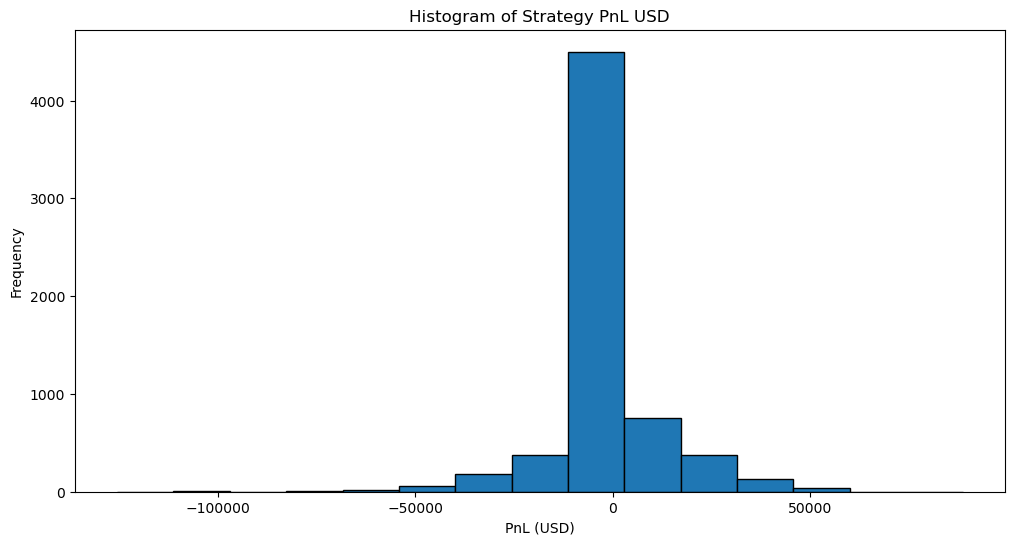

In [15]:
import matplotlib.pyplot as plt

# Plot histogram of Strategy_PnL_USD
plt.figure(figsize=(12, 6))
plt.hist(estest_long['Strategy_PnL_USD'], bins=15, edgecolor='black')
plt.title('Histogram of Strategy PnL USD')
plt.xlabel('PnL (USD)')
plt.ylabel('Frequency')
plt.show()